# Netflix Subscriptions Forecasting

In this project, we will use Python to forecast Netflix subscriber growth using time series analysis to help drive data-driven strategies for financial planning, content creation, and operational efficiency.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTQFo8vtEwsMPVjm28sqds7a5aYPKdnrDZxsqqsHlY5Hw&s=10' width='750'>

In [1]:
#Librarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.express as px
import plotly.io as pio
from statsmodels.tsa.arima.model import ARIMA

### EDA 

In [2]:
df=pd.read_csv('Netflix-Subscriptions.csv')

In [3]:
df.head()

,Time Period,Subscribers
0,01/04/2013,34240000
1,01/07/2013,35640000
2,01/10/2013,38010000
3,01/01/2014,41430000
4,01/04/2014,46130000


In [4]:
df.tail()

,Time Period,Subscribers
37,01/07/2022,220670000
38,01/10/2022,223090000
39,01/01/2023,230750000
40,01/04/2023,232500000
41,01/07/2023,238390000


In [5]:
df.shape

(42, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Time Period  42 non-null     object
 1   Subscribers  42 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 804.0+ bytes


In [7]:
df.isnull().sum()

Time Period    0
Subscribers    0
dtype: int64

In [8]:
df['Time Period'].value_counts()

Time Period
01/04/2013    1
01/01/2021    1
01/01/2019    1
01/04/2019    1
01/07/2019    1
01/10/2019    1
01/01/2020    1
01/04/2020    1
01/07/2020    1
01/10/2020    1
01/04/2021    1
01/07/2013    1
01/07/2021    1
01/10/2021    1
01/01/2022    1
01/04/2022    1
01/07/2022    1
01/10/2022    1
01/01/2023    1
01/04/2023    1
01/10/2018    1
01/07/2018    1
01/04/2018    1
01/01/2018    1
01/10/2013    1
01/01/2014    1
01/04/2014    1
01/07/2014    1
01/10/2014    1
01/01/2015    1
01/04/2015    1
01/07/2015    1
01/10/2015    1
01/01/2016    1
01/04/2016    1
01/07/2016    1
01/10/2016    1
01/01/2017    1
01/04/2017    1
01/07/2017    1
01/10/2017    1
01/07/2023    1
Name: count, dtype: int64

In [9]:
df.describe()

,Subscribers
count,4.200000e+01
mean,1.304243e+08
std,6.891896e+07
min,3.424000e+07
25%,6.722500e+07
50%,1.216250e+08
75%,2.015325e+08
max,2.383900e+08


In [10]:
df['Time Period'] = pd.to_datetime(df['Time Period'], format='%d/%m/%Y')

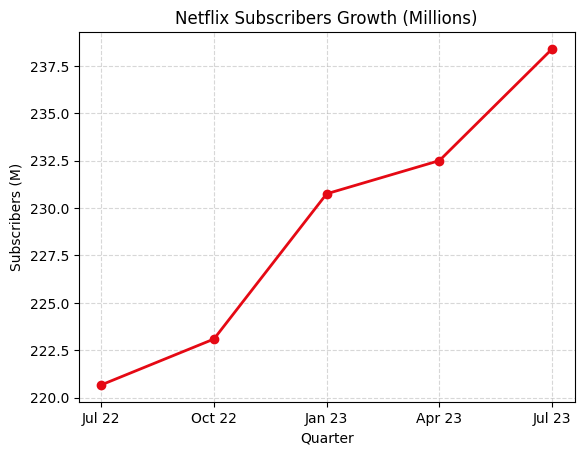

In [11]:
recent = df.tail(5)
 
plt.plot(recent['Time Period'].dt.strftime('%b %y'), recent['Subscribers'] / 1e6,
         marker='o', color='#E50914', linewidth=2)
plt.title('Netflix Subscribers Growth (Millions)')
plt.xlabel('Quarter')
plt.ylabel('Subscribers (M)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [12]:
df.head()

,Time Period,Subscribers
0,2013-04-01,34240000
1,2013-07-01,35640000
2,2013-10-01,38010000
3,2014-01-01,41430000
4,2014-04-01,46130000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Time Period  42 non-null     datetime64[ns]
 1   Subscribers  42 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 804.0 bytes


In [14]:
import plotly.express as px

# Calculate growth rate
df['Quarterly Growth Rate'] = df['Subscribers'].pct_change() * 100

# Plot bar chart
fig = px.bar(
    df, 
    x='Time Period', 
    y='Quarterly Growth Rate',
    color=df['Quarterly Growth Rate'] > 0,
    color_discrete_map={True: 'green', False: 'red'},
    title='Netflix Quarterly Subscriptions Growth Rate',
    labels={'Quarterly Growth Rate': 'Quarterly Growth Rate (%)'}
)
fig.show()

In [15]:
df['Yearly Growth'] = df['Subscribers'].pct_change(periods=4) * 100
yoy = df.dropna(subset=['Yearly Growth'])
 
fig = px.bar(
    yoy,
    x='Time Period',
    y='Yearly Growth',
    color=yoy['Yearly Growth'] > 0,
    color_discrete_map={True: 'green', False: 'red'},
    title='Netflix Year-over-Year Subscriber Growth Rate',
    labels={'Yearly Growth': 'YoY Growth Rate (%)'}
)
fig.update_layout(showlegend=False)
fig.show()

In [16]:
time_series = df.set_index('Time Period')['Subscribers']

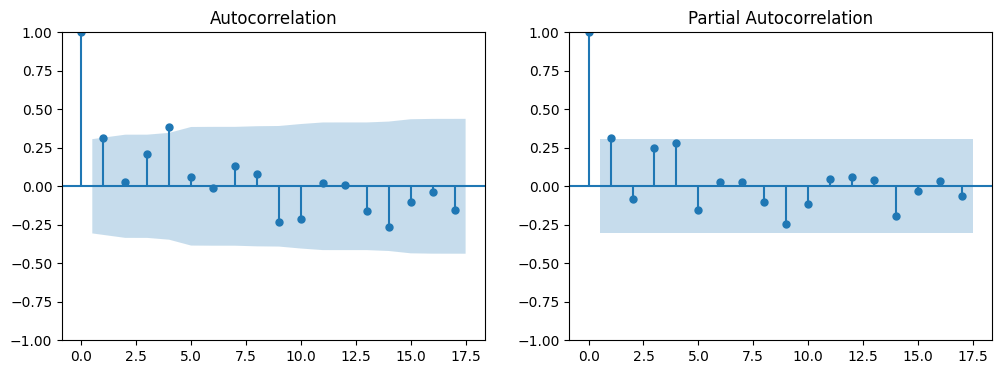

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
differenced_series = time_series.diff().dropna()

# Plot ACF and PACF of differenced time series
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(differenced_series, ax=axes[0])
plot_pacf(differenced_series, ax=axes[1])
plt.show()

### Modeling

In [18]:
p, d, q = 1, 1, 1
model = ARIMA(time_series, order=(p, d, q))
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:            Subscribers   No. Observations:                   42
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -672.993
Date:                Tue, 06 Oct 2026   AIC                           1351.986
Time:                        15:28:08   BIC                           1357.127
Sample:                    04-01-2013   HQIC                          1353.858
                         - 07-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9997      0.012     80.764      0.000       0.975       1.024
ma.L1         -0.9908      0.221     -4.476      0.000      -1.425      -0.557
sigma2      1.187e+13   1.57e-14   7.57e+26      0.0

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-OCT will be used.

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-OCT will be used.

C:\Users\furka\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency QS-OCT will be used.



In [19]:
future_steps = 5
predictions = results.predict(len(time_series), len(time_series) + future_steps - 1)
predictions = predictions.astype(int)

In [20]:
print((predictions / 1e6).round(2).rename('Forecast (millions)'))
print("\nReaches 250M within the horizon:", (predictions >= 250_000_000).any())

2023-10-01    243.32
2024-01-01    248.25
2024-04-01    253.18
2024-07-01    258.11
2024-10-01    263.03
Freq: QS-OCT, Name: Forecast (millions), dtype: float64

Reaches 250M within the horizon: True


### Model Evaluation

In [21]:
import warnings
warnings.filterwarnings('ignore')
 
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
 
test_size = 6
train = time_series.iloc[:-test_size]
test = time_series.iloc[-test_size:]
 
print("Train:", train.shape, "| Test:", test.shape)

Train: (36,) | Test: (6,)


In [22]:
#Fit ARIMA, SARIMA and baseline on the training set
arima_fit = ARIMA(train, order=(1, 1, 1)).fit()
arima_pred = pd.Series(np.asarray(arima_fit.forecast(steps=test_size)), index=test.index)

In [23]:
# quarterly data -> seasonal period of 4
sarima_fit = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 4)).fit(disp=False)
sarima_pred = pd.Series(np.asarray(sarima_fit.forecast(steps=test_size)), index=test.index)
 
naive_pred = pd.Series(train.iloc[-1], index=test.index)

In [24]:
#
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred) / 1e6
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) / 1e6
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape
 
scores = pd.DataFrame(
    [evaluate(test, arima_pred), evaluate(test, sarima_pred), evaluate(test, naive_pred)],
    columns=['MAE (M)', 'RMSE (M)', 'MAPE (%)'],
    index=['ARIMA(1,1,1)', 'SARIMA(1,1,1)(1,1,1,4)', 'Naive baseline']
).round(3)
 
print("AIC  ARIMA:", round(arima_fit.aic, 2), "| SARIMA:", round(sarima_fit.aic, 2))
scores

AIC  ARIMA: 1151.75 | SARIMA: 1026.46


,MAE (M),RMSE (M),MAPE (%)
"ARIMA(1,1,1)",12.671,13.155,5.539
"SARIMA(1,1,1)(1,1,1,4)",12.997,13.523,5.673
Naive baseline,6.457,8.850,2.762


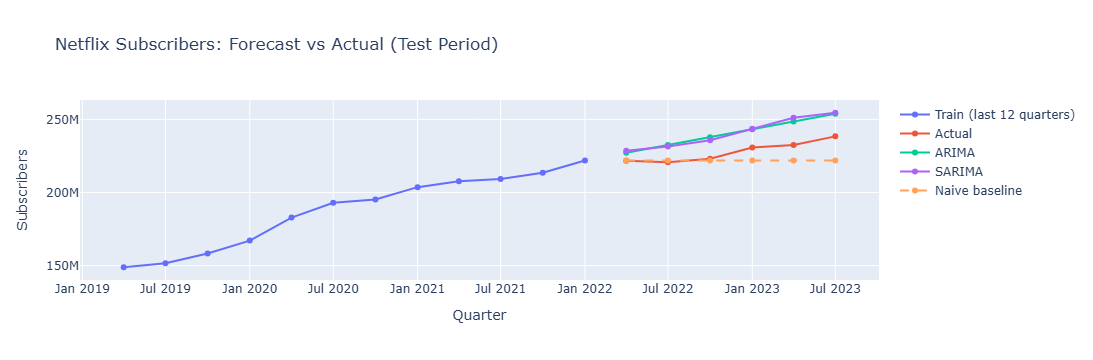

In [25]:
# Plot: test period, actual vs predictions
fig = go.Figure()
fig.add_trace(go.Scatter(x=train.index[-12:], y=train.iloc[-12:], name='Train (last 12 quarters)'))
fig.add_trace(go.Scatter(x=test.index, y=test, name='Actual'))
fig.add_trace(go.Scatter(x=arima_pred.index, y=arima_pred, name='ARIMA'))
fig.add_trace(go.Scatter(x=sarima_pred.index, y=sarima_pred, name='SARIMA'))
fig.add_trace(go.Scatter(x=naive_pred.index, y=naive_pred, name='Naive baseline', line=dict(dash='dash')))
fig.update_layout(title='Netflix Subscribers: Forecast vs Actual (Test Period)',
                  xaxis_title='Quarter', yaxis_title='Subscribers')
fig.show()

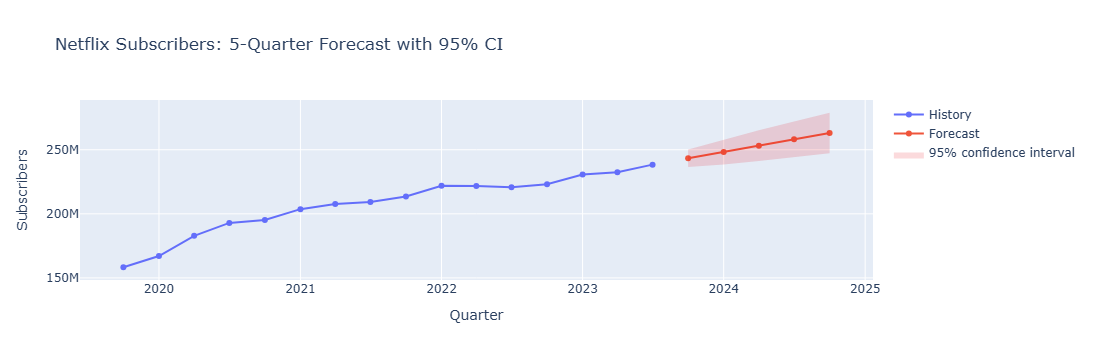

In [26]:
# Final forecast with confidence interval (refit on all data)
final_fit = ARIMA(time_series, order=(1, 1, 1)).fit()
future = final_fit.get_forecast(steps=5)
 
future_mean = future.predicted_mean
future_ci = future.conf_int()
future_ci.columns = ['lower', 'upper']
 
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_series.index[-16:], y=time_series.iloc[-16:], name='History'))
fig.add_trace(go.Scatter(x=future_mean.index, y=future_mean, name='Forecast'))
fig.add_trace(go.Scatter(
    x=list(future_ci.index) + list(future_ci.index[::-1]),
    y=list(future_ci['upper']) + list(future_ci['lower'][::-1]),
    fill='toself', fillcolor='rgba(229,9,20,0.15)',
    line=dict(color='rgba(255,255,255,0)'), name='95% confidence interval'
))
fig.update_layout(title='Netflix Subscribers: 5-Quarter Forecast with 95% CI',
                  xaxis_title='Quarter', yaxis_title='Subscribers')
fig.show()

### Conclusion

- **Forecast:** The ARIMA(1,1,1) model projects Netflix subscribers to rise from 238.4M (Jul 2023) to about 263M by Oct 2024, passing 250M in the April 2024 quarter (about 253M).
- **Backtest:** On the last 6 quarters, a naive baseline ("next quarter = last quarter") clearly outperformed both models (MAE 6.46M vs. 12.67M for ARIMA and 13.00M for SARIMA; MAPE 2.76% vs. 5.54% and 5.67%). Adding seasonality did not help either: SARIMA had a lower AIC on the training set but a higher test error.
- **Why:** The AR coefficient is almost 1 (0.9997), so the model keeps extrapolating the earlier, faster growth. Subscriber growth in the test window was slower, so the forecasts overshoot.
- **Takeaway:** The 250M projection should be read as an optimistic estimate, not a reliable prediction. With only 42 quarterly observations and a clear change in growth pace, a simple model struggles. Next steps would be walk-forward validation, modeling growth rates instead of raw counts, and comparing against ETS or Prophet.